# Proyecto empresa aliada: entregable 6

## 1. Cargar y preparar los datos:

In [99]:
import pandas as pd
!pip install pmdarima
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from pmdarima import auto_arima

import warnings
warnings.filterwarnings('ignore')

# 1. Cargar datos
df = pd.read_csv("FACT_SALES.csv")
df.head()


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


### a. Convertir WEEK a una fecha usable

In [3]:
# Separar semana y año
df[['WEEK_NUM', 'YEAR']] = df['WEEK'].str.split('-', expand=True)
df['WEEK_NUM'] = df['WEEK_NUM'].astype(int)
df['YEAR'] = df['YEAR'].astype(int)

# Convertir año de 2 dígitos a 4 dígitos
df['YEAR'] = df['YEAR'].apply(lambda x: 2000 + x if x < 100 else x)

# Crear fecha base: 1 de enero del año
df['FECHA'] = pd.to_datetime(df['YEAR'].astype(str) + '-01-01')

# Sumar semanas (WEEK_NUM - 1) * 7 días
df['FECHA'] = df['FECHA'] + pd.to_timedelta((df['WEEK_NUM'] - 1) * 7, unit='D')

df[['WEEK', 'YEAR', 'WEEK_NUM', 'FECHA']].head()


,WEEK,YEAR,WEEK_NUM,FECHA
0,34-22,2022,34,2022-08-20
1,34-22,2022,34,2022-08-20
2,34-22,2022,34,2022-08-20
3,34-22,2022,34,2022-08-20
4,34-22,2022,34,2022-08-20


In [4]:
df['FECHA'].isna().sum()


np.int64(0)

In [5]:
df['FECHA'].head()


0   2022-08-20
1   2022-08-20
2   2022-08-20
3   2022-08-20
4   2022-08-20
Name: FECHA, dtype: datetime64[us]

In [6]:
catalogo = pd.read_excel("DIM_PRODUCT.xlsx")

catalogo.columns


Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3'],
      dtype='str')

In [7]:
catalogo.head()

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [8]:
# Limpiar filas ITEM
catalogo = catalogo[catalogo['ITEM'].notna()]

# Códigos de Vanish
vanish_codes = (
    catalogo[catalogo['BRAND'].str.contains("VANISH", case=False)]
    ['ITEM']
    .unique()
    .tolist()
)

# Códigos de Lysol
lysol_codes = (
    catalogo[catalogo['BRAND'].str.contains("LYSOL", case=False)]
    ['ITEM']
    .unique()
    .tolist()
)

len(vanish_codes), len(lysol_codes)


(118, 8)

In [9]:
catalogo .columns

Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3'],
      dtype='str')

In [10]:
df_vanish = df[df['ITEM_CODE'].isin(vanish_codes)].copy()
df_lysol  = df[df['ITEM_CODE'].isin(lysol_codes)].copy()

In [11]:
# Agregar ventas por semana
df_vanish_w = (
    df_vanish.groupby('FECHA')['TOTAL_UNIT_SALES']
    .sum()
    .to_frame(name='VENTAS')
)

df_lysol_w = (
    df_lysol.groupby('FECHA')['TOTAL_UNIT_SALES']
    .sum()
    .to_frame(name='VENTAS')
)


In [12]:
# Split temporal (últimos 6 meses)
fecha_max = df_vanish_w.index.max()
fecha_corte = fecha_max - pd.DateOffset(months=6)

train = df_vanish_w[df_vanish_w.index < fecha_corte]
test  = df_vanish_w[df_vanish_w.index >= fecha_corte]


In [13]:
df_vanish_w.shape


(80, 1)

In [14]:
df_vanish_w.head()


,VENTAS
FECHA,
2022-01-01,721.613
2022-01-08,681.153
2022-01-15,580.365
2022-01-22,581.081
2022-01-29,623.471


In [15]:
df_vanish_w.tail()

,VENTAS
FECHA,
2023-06-11,733.463
2023-06-18,716.655
2023-06-25,783.118
2023-07-02,788.907
2023-07-09,724.247


In [16]:
set(df['ITEM_CODE']).intersection(set(catalogo['ITEM']))


{'0000075000592',
 '0000075000608',
 '0000075000615',
 '0000075000622',
 '0000075000639',
 '0000075000677',
 '0000075000684',
 '0019200958714',
 '0037000018704',
 '0044600305974',
 '0044600313429',
 '0044600313719',
 '0046500022517',
 '0046500022692',
 '0046500022746',
 '0046500222979',
 '0046500729355',
 '0123456808218',
 '0612464080148',
 '0616533000525',
 '0722429128034',
 '0732913227013',
 '0737128047005',
 '0737128127004',
 '0737128247009',
 '0741120000005',
 '0741120000012',
 '0741120000029',
 '0741120000036',
 '0741120000746',
 '0757037000489',
 '0757037512449',
 '0757037513552',
 '0757037516935',
 '0757037517123',
 '3045200760009',
 '3045206360609',
 '3045206382007',
 '4008455394015',
 '4008455394114',
 '4008455394213',
 '4008455394411',
 '4008455394510',
 '4008455394619',
 '4008455423517',
 '4008455423616',
 '4008455423715',
 '4008455425412',
 '4008455427614',
 '4008455438016',
 '4008455457512',
 '4008455457710',
 '4008455458618',
 '4008455458717',
 '4008455459417',
 '40084554

In [17]:
df['ITEM_CODE'] = df['ITEM_CODE'].astype(str)
catalogo['ITEM'] = catalogo['ITEM'].astype(str)


In [18]:
df['ITEM_CODE'] = df['ITEM_CODE'].str.strip()
catalogo['ITEM'] = catalogo['ITEM'].str.strip()


In [19]:
set(df['ITEM_CODE']).intersection(set(catalogo['ITEM']))


{'0000075000592',
 '0000075000608',
 '0000075000615',
 '0000075000622',
 '0000075000639',
 '0000075000677',
 '0000075000684',
 '0019200958714',
 '0037000018704',
 '0044600305974',
 '0044600313429',
 '0044600313719',
 '0046500022517',
 '0046500022692',
 '0046500022746',
 '0046500222979',
 '0046500729355',
 '0123456808218',
 '0612464080148',
 '0616533000525',
 '0722429128034',
 '0732913227013',
 '0737128047005',
 '0737128127004',
 '0737128247009',
 '0741120000005',
 '0741120000012',
 '0741120000029',
 '0741120000036',
 '0741120000746',
 '0757037000489',
 '0757037512449',
 '0757037513552',
 '0757037516935',
 '0757037517123',
 '3045200760009',
 '3045206360609',
 '3045206382007',
 '4008455394015',
 '4008455394114',
 '4008455394213',
 '4008455394411',
 '4008455394510',
 '4008455394619',
 '4008455423517',
 '4008455423616',
 '4008455423715',
 '4008455425412',
 '4008455427614',
 '4008455438016',
 '4008455457512',
 '4008455457710',
 '4008455458618',
 '4008455458717',
 '4008455459417',
 '40084554

In [20]:
df_vanish_w.shape

(80, 1)

In [21]:
set(df['ITEM_CODE']).intersection(set(catalogo['ITEM']))


{'0000075000592',
 '0000075000608',
 '0000075000615',
 '0000075000622',
 '0000075000639',
 '0000075000677',
 '0000075000684',
 '0019200958714',
 '0037000018704',
 '0044600305974',
 '0044600313429',
 '0044600313719',
 '0046500022517',
 '0046500022692',
 '0046500022746',
 '0046500222979',
 '0046500729355',
 '0123456808218',
 '0612464080148',
 '0616533000525',
 '0722429128034',
 '0732913227013',
 '0737128047005',
 '0737128127004',
 '0737128247009',
 '0741120000005',
 '0741120000012',
 '0741120000029',
 '0741120000036',
 '0741120000746',
 '0757037000489',
 '0757037512449',
 '0757037513552',
 '0757037516935',
 '0757037517123',
 '3045200760009',
 '3045206360609',
 '3045206382007',
 '4008455394015',
 '4008455394114',
 '4008455394213',
 '4008455394411',
 '4008455394510',
 '4008455394619',
 '4008455423517',
 '4008455423616',
 '4008455423715',
 '4008455425412',
 '4008455427614',
 '4008455438016',
 '4008455457512',
 '4008455457710',
 '4008455458618',
 '4008455458717',
 '4008455459417',
 '40084554

In [22]:
df['ITEM_CODE'].head()

0    7501058792808BP2
1       7501058715883
2       7702626213774
3       7501058716422
4       7501058784353
Name: ITEM_CODE, dtype: str

In [23]:
catalogo['ITEM'].head()

0    0000075000592
1    0000075000608
2    0000075000615
3    0000075000622
4    0000075000639
Name: ITEM, dtype: str

## 2. Seleccionar la técnica de modelado:

## 3. Dividir los datos en conjuntos de entrenamiento y prueba:

In [33]:
fecha_corte = fecha_max - pd.DateOffset(months=6)
train = df_vanish_w[df_vanish_w.index < fecha_corte]
test  = df_vanish_w[df_vanish_w.index >= fecha_corte]
train.head()

,VENTAS
FECHA,
2022-01-01,721.613
2022-01-08,681.153
2022-01-15,580.365
2022-01-22,581.081
2022-01-29,623.471


In [35]:
train.head()

,VENTAS
FECHA,
2022-01-01,721.613
2022-01-08,681.153
2022-01-15,580.365
2022-01-22,581.081
2022-01-29,623.471


In [36]:
train.describe()

,VENTAS
count,54.000000
mean,677.866167
std,67.334692
min,561.844000
25%,635.833250
50%,664.493500
75%,708.328000
max,873.922000


<Axes: title={'center': 'Serie Vanish - Train'}, xlabel='FECHA'>

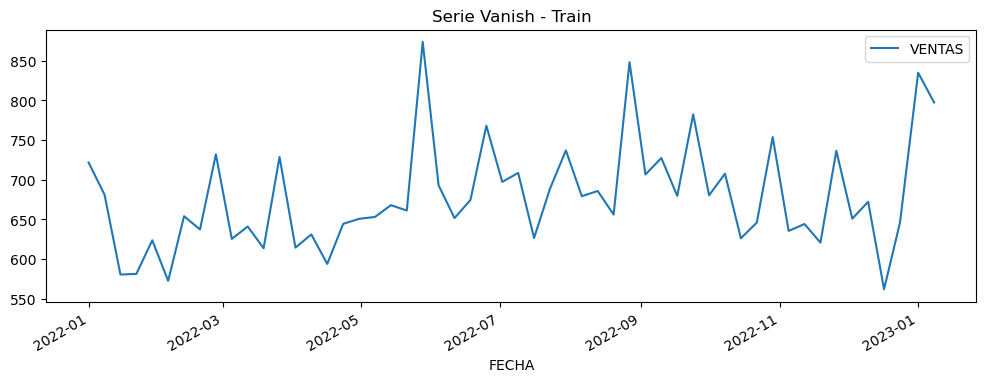

In [37]:
train.plot(figsize=(12,4), title="Serie Vanish - Train")


In [38]:
train.shape

(54, 1)

In [39]:
test.shape

(26, 1)

## 4. Construir y entrenar el modelo predictivo:

In [42]:
model = auto_arima(
    train['VENTAS'],
    seasonal=True,
    m=52,
    D=0,      
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=611.622, Time=8.10 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=610.881, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=613.024, Time=4.23 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=612.940, Time=2.02 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=859.812, Time=0.05 sec
 ARIMA(0,0,0)(1,0,0)[52] intercept   : AIC=612.880, Time=0.41 sec
 ARIMA(0,0,0)(0,0,1)[52] intercept   : AIC=612.475, Time=0.95 sec
 ARIMA(0,0,0)(1,0,1)[52] intercept   : AIC=614.475, Time=1.35 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=611.079, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[52] intercept   : AIC=611.325, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[52] intercept   : AIC=613.099, Time=0.07 sec

Best model:  ARIMA(0,0,0)(0,0,0)[52] intercept
Total fit time: 17.365 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   54
Model:                        SARIMAX   Log Likelihood                -303.440
Date:                Mon, 25 May 2026   AIC                            610.881
Time:                        13:03:44   BIC                            614.859
Sample:                             0   HQIC                           612.415
                                 - 54                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    677.8662     10.778     62.896      0.000     656.742     698.990
sigma2      4449.9986    863.410      5.154      0.000    2757.745    6142.252
===================================================================================
Ljung-Box (L1) (Q):                   1.78   Jarque-Bera (JB):                 8.60
Prob(Q):                              0.18   Prob(JB):                         0.01
Heteroskedasticity (H):               1.33   Skew:                             0.90
Prob(H) (two-sided):                  0.56   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 5. Validar el modelo:

In [ ]:
forecast = model.predict(n_periods=len(test)).values


In [ ]:
# 1. Predicciones corregidas
forecast = model.predict(n_periods=len(test)).values

pred_series = pd.Series(
    forecast,
    index=test.index,
    name='PRONOSTICO'
)

# 2. Construir df_eval
df_eval = pd.concat([test['VENTAS'], pred_series], axis=1)
df_eval.columns = ['y_true', 'y_pred']
df_eval = df_eval.dropna()

df_eval.shape


In [73]:
df_eval.shape

(26, 2)

### a. Calcular métricas de error (MSE, MAE, MAPE)

In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_true = df_eval['y_true']
y_pred = df_eval['y_pred']

mse  = mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MSE : {mse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")


MSE : 7411.41
MAE : 70.09
MAPE: 9.40%


### b. Realiza un gráfico de las predicciones

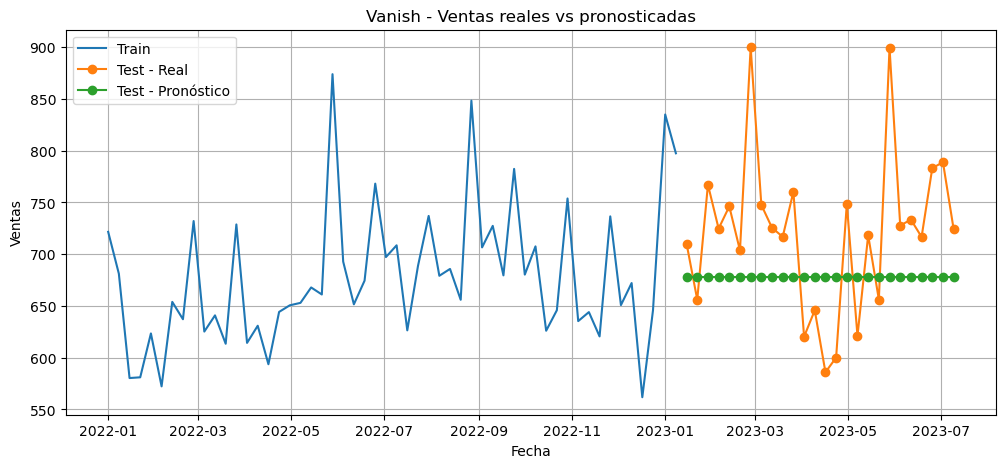

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train.index, train['VENTAS'], label='Train')
plt.plot(test.index, test['VENTAS'], label='Test - Real', marker='o')
plt.plot(df_eval.index, df_eval['y_pred'], label='Test - Pronóstico', marker='o')
plt.title('Vanish - Ventas reales vs pronosticadas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


## 6. Ajustar y optimizar el modelo:

#### Probar SARIMA sin estacionalidad

In [ ]:
model_no_season = auto_arima(
    train['VENTAS'],
    seasonal=False,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

forecast_no_season = model_no_season.predict(n_periods=len(test)).values
pred_no_season = pd.Series(forecast_no_season, index=test.index)

mse_ns, mae_ns, mape_ns = evaluar(test['VENTAS'], pred_no_season)



#### Probar SARIMA con m=2 (estacionalidad muy suave)

In [ ]:
model_m2 = auto_arima(
    train['VENTAS'],
    seasonal=True,
    m=2,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

forecast_m2 = model_m2.predict(n_periods=len(test)).values
pred_m2 = pd.Series(forecast_m2, index=test.index)

mse_m2, mae_m2, mape_m2 = evaluar(test['VENTAS'], pred_m2)


#### Probar ARIMA manual

In [ ]:
from pmdarima.arima import ARIMA

model_manual = ARIMA(order=(2,1,2))
model_manual.fit(train['VENTAS'])

forecast_manual = model_manual.predict(n_periods=len(test)).values
pred_manual = pd.Series(forecast_manual, index=test.index)

mse_man, mae_man, mape_man = evaluar(test['VENTAS'], pred_manual)


#### a. Documenta los cambios

In [102]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['SARIMA m=4 (base)', 'ARIMA sin estacionalidad',
               'SARIMA m=2', 'ARIMA manual (2,1,2)'],
    'MSE':  [mse_base, mse_ns, mse_m2, mse_man],
    'MAE':  [mae_base, mae_ns, mae_m2, mae_man],
    'MAPE': [mape_base, mape_ns, mape_m2, mape_man]
})

resultados


,Modelo,MSE,MAE,MAPE
0,SARIMA m=4 (base),6884.825423,64.801628,8.710758
1,ARIMA sin estacionalidad,7411.413746,70.093192,9.400777
2,SARIMA m=2,5371.483300,53.466228,7.601798
3,"ARIMA manual (2,1,2)",5715.974908,54.867625,7.799963


### 7. Generar las predicciones futuras:

In [90]:
df.columns

Index(['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
       'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION'],
      dtype='str')

In [91]:
df.index

RangeIndex(start=0, stop=122002, step=1)

In [98]:
# Número de semanas a pronosticar
n_future = 12

# Pronóstico futuro
future_forecast = model_m2.predict(n_periods=n_future).values

# Última fecha real de la serie
last_date = test.index.max()

# Crear índice futuro
future_index = pd.date_range(
    start=last_date + pd.Timedelta(weeks=1),
    periods=n_future,
    freq='W'
)

# Serie futura
future_series = pd.Series(
    future_forecast,
    index=future_index,
    name='PRONOSTICO_FUTURO'
)

future_series


2023-07-16    637.654971
2023-07-23    687.927745
2023-07-30    780.192481
2023-08-06    767.078660
2023-08-13    677.220236
2023-08-20    709.898291
2023-08-27    751.609659
2023-09-03    751.206652
2023-09-10    697.869097
2023-09-17    721.364580
2023-09-24    736.692466
2023-10-01    742.923152
Freq: W-SUN, Name: PRONOSTICO_FUTURO, dtype: float64

In [100]:
tabla_futuro = pd.DataFrame({
    'FECHA': future_series.index,
    'PRONOSTICO_VENTAS': future_series.values
})

tabla_futuro


,FECHA,PRONOSTICO_VENTAS
0,2023-07-16,637.654971
1,2023-07-23,687.927745
2,2023-07-30,780.192481
3,2023-08-06,767.078660
4,2023-08-13,677.220236
5,2023-08-20,709.898291
6,2023-08-27,751.609659
7,2023-09-03,751.206652
8,2023-09-10,697.869097
9,2023-09-17,721.364580


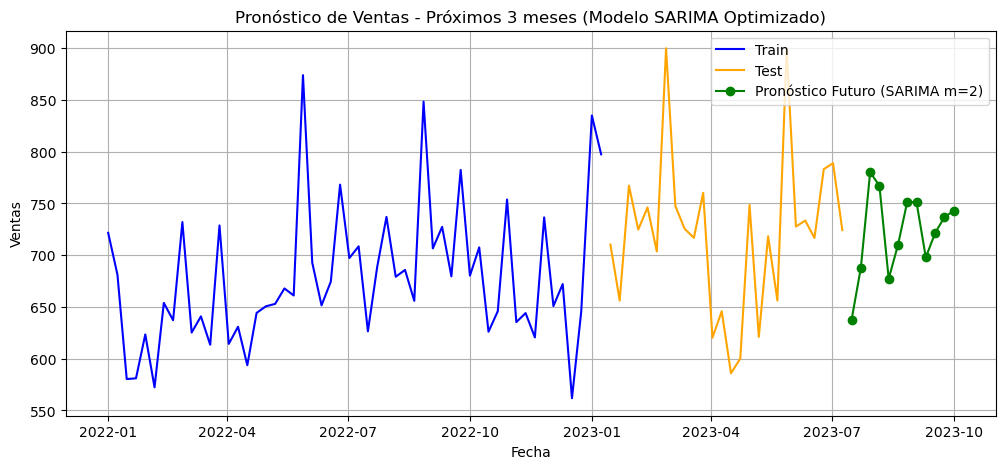

In [101]:
plt.figure(figsize=(12,5))

# Histórico completo
plt.plot(train.index, train['VENTAS'], label='Train', color='blue')
plt.plot(test.index, test['VENTAS'], label='Test', color='orange')

# Pronóstico futuro
plt.plot(future_series.index, future_series.values,
         label='Pronóstico Futuro (SARIMA m=2)', marker='o', color='green')

plt.title('Pronóstico de Ventas - Próximos 3 meses (Modelo SARIMA Optimizado)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()
plt.show()
